# Can you go the to the beach
Our indexs:
- UV (should you put sunscreen on)
- cloud coverage
- Tide
- Hurricanes
- Water conditions : ripe tide, red tide, wave height, Temperature of the water
- Is it raining
- Temperature outside (too cold or too hot)
- wind

## For our map 
- Focus on the east side because the west coast doesn't get mainly hazarda
- example december it will be a good beach day in Florida but not in Maine
example december it will be a good beach day in Florida but not in Maine

## Hazard we choose 
Hurricane isaias beacuse the path was up the whole east coast however it was at its strongest a categrory 1

- UGRD and VGRD (u and v compenents of the wind)
- TCDC (total cloud coverage)
- TMP (temperature)
- APCP (total precipation)
- DPT (dewpoint)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

In [2]:
ds = xr.open_dataset("/courses/meteo473/sp26/473_sp26_group3/beachday_new.nc")
ds_time = ds.isel(valid_time=5)

sh: 1: getfattr: not found


In [3]:
ds_time['prate']

<xarray.DataArray 'prate' (latitude: 101, longitude: 161)> Size: 65kB
[16261 values with dtype=float32]
Coordinates:
  * latitude           (latitude) float64 808B 50.0 49.75 49.5 ... 25.25 25.0
  * longitude          (longitude) float64 1kB 260.0 260.2 260.5 ... 299.8 300.0
    valid_time         datetime64[ns] 8B 2025-07-02T18:00:00
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
    atmosphere         float64 8B ...
Attributes: (12/30)
    GRIB_paramId:                             3059
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_name:                                Precipitation rate
    GRIB_shortName:                           prate
    GRIB_units:                               kg m**-2 s**-1
    long_name:                                Precipitation rate
    units:                                    kg m**-2 s**-1
    standard_name:                            unknown

In [12]:
#adjuct variable names 
u= ds_time['u10']
v= ds_time['v10']
temp= ds_time['t2m']
cloud= ds_time['tcc']
precip= ds_time['tp']
dewpoint= ds_time['d2m']

In [13]:
#calculate wind speed 
wind= np.sqrt(u**2 +v**2)
wind_mph= wind*2.23693629 
# Temperature conversion
temp_F = (temp - 273.15) * (9/5) + 32
# Dew point conversion
dpt_F = (dewpoint - 273.15) * (9/5) + 32
#precip conversion
precip_in= precip / 25.399999830047

<function matplotlib.pyplot.show(close=None, block=None)>

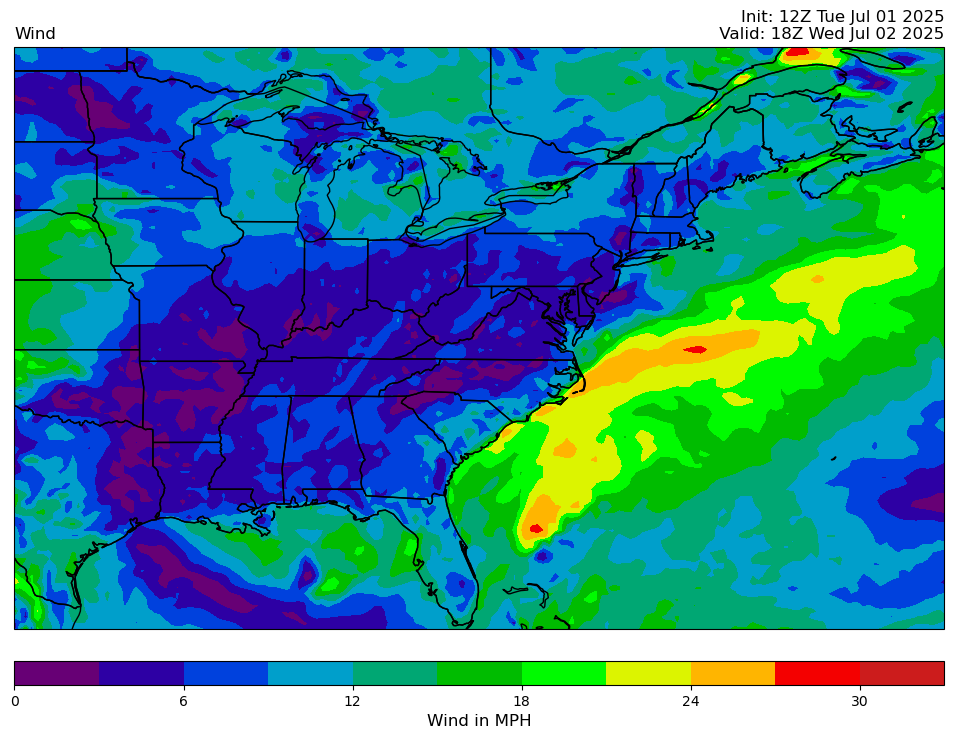

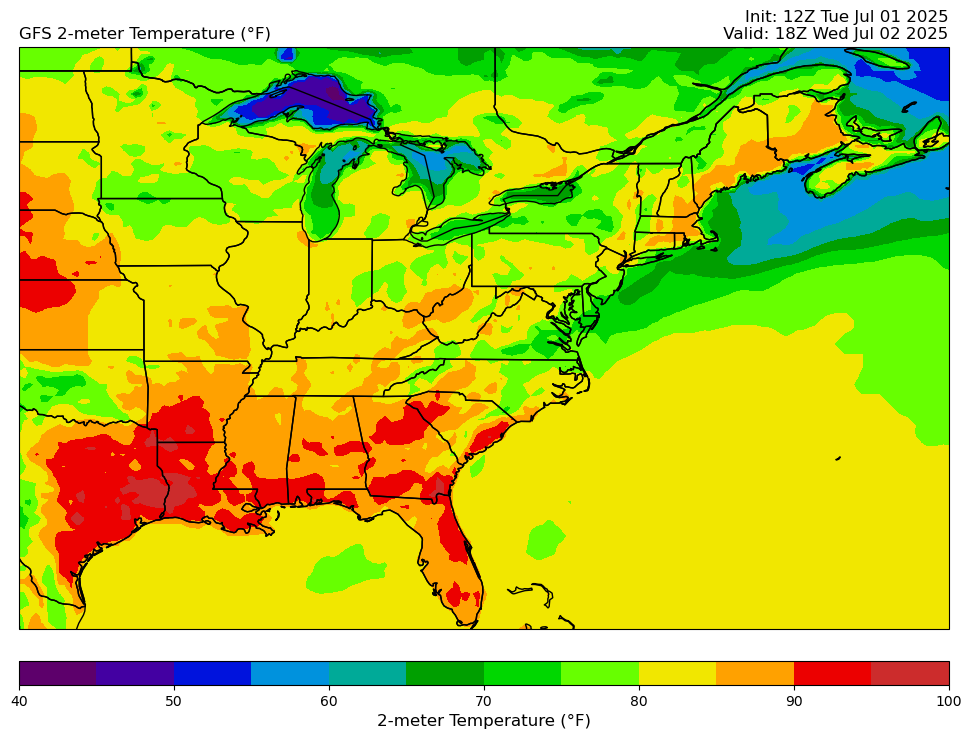

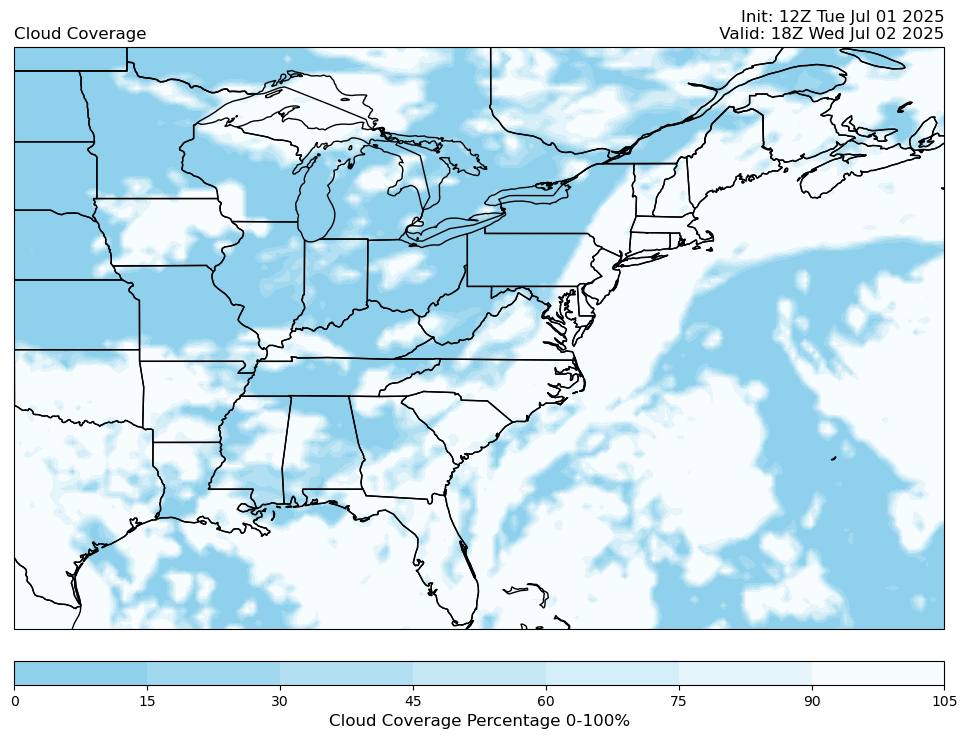

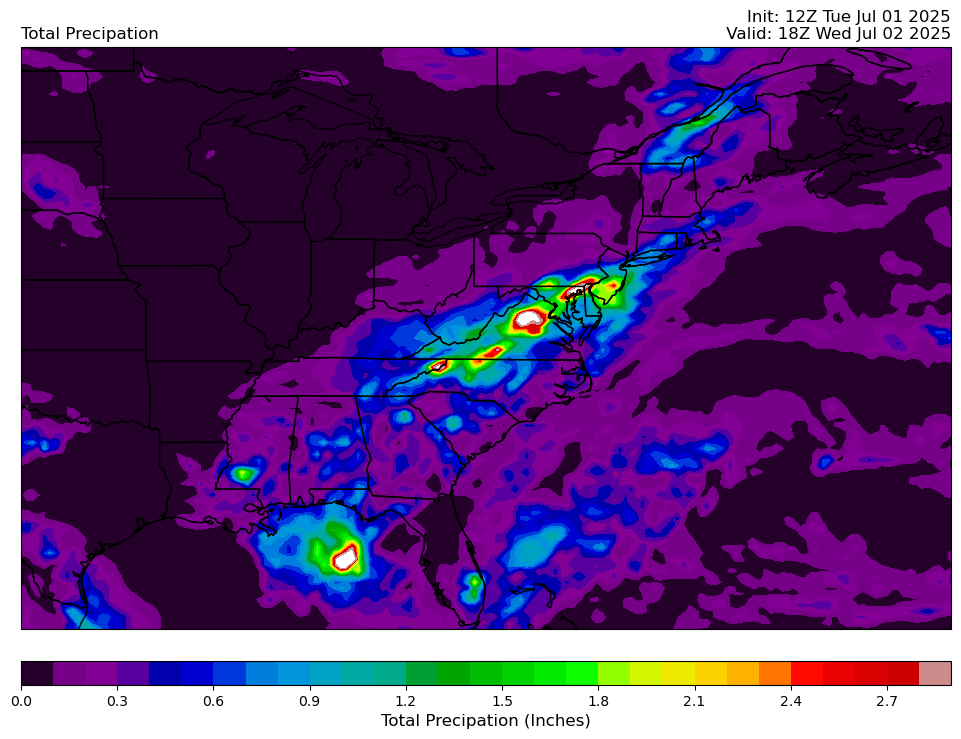

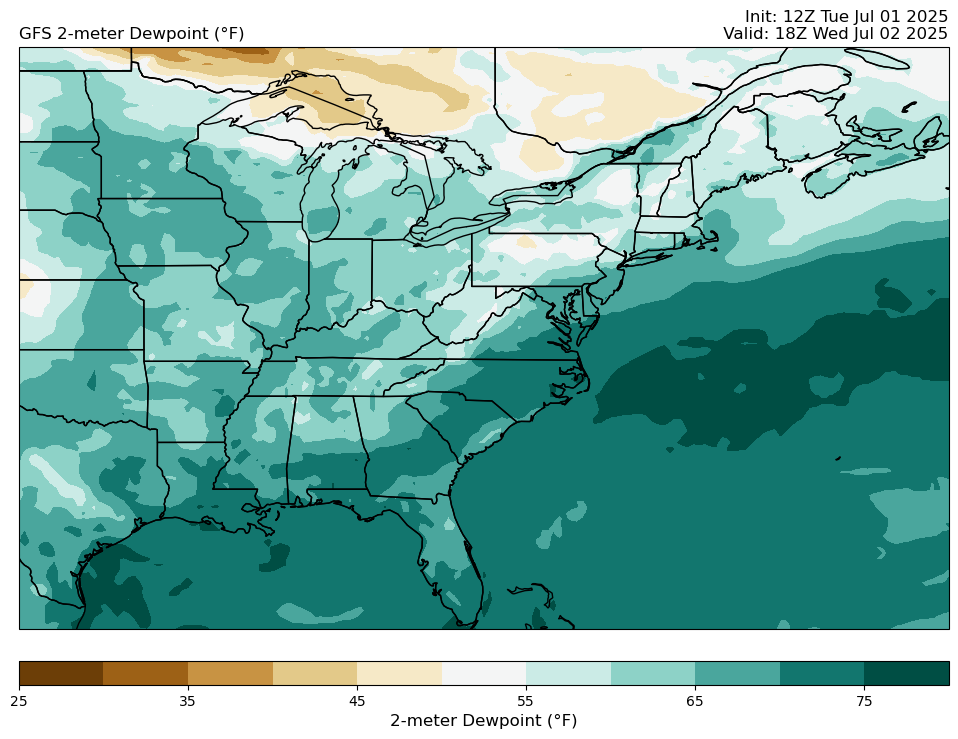

In [14]:
#base map
def base_map():
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    return fig, ax

# wind speed map 
fig, ax = base_map()
wind_levels = np.arange(0, 35, 3)
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.03])
contour_wind = ax.contourf(ds_time['longitude'], ds_time['latitude'], wind_mph, levels=wind_levels, cmap='nipy_spectral', transform=ccrs.PlateCarree())
wind_color_bar = plt.colorbar(contour_wind, cax=cbar_ax, orientation='horizontal', pad=0.05)
wind_color_bar.set_label('Wind in MPH', fontsize=12)
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('Wind', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)
plt.show  

#Temperature map
temp_F = (ds_time['t2m'] - 273.15) * (9/5) + 32
temp_levels = np.arange(40, 105, 5)
fig, ax = base_map()
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.03])
contour_temp = ax.contourf(ds_time['longitude'], ds_time['latitude'], temp_F, levels=temp_levels, cmap='nipy_spectral', transform=ccrs.PlateCarree())
temp_color_bar = plt.colorbar(contour_temp, cax=cbar_ax, orientation='horizontal', pad=0.05)
temp_color_bar.set_label('2-meter Temperature (°F)', fontsize=12)
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('GFS 2-meter Temperature (°F)', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)
plt.show 

#cloud map 
fig, ax = base_map()
colors = [
    (135/255, 206/255, 235/255),  # Sky blue
    (1, 1, 1)                      # White
]
cloud_cmap = LinearSegmentedColormap.from_list("SkyBlueToWhite", colors, N=256) #costum colormap
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.03])
contour_cloud = ax.contourf(ds_time['longitude'], ds_time['latitude'], cloud, cmap= cloud_cmap , transform=ccrs.PlateCarree())
temp_color_bar = plt.colorbar(contour_cloud, cax=cbar_ax, orientation='horizontal', pad=0.05)
temp_color_bar.set_label('Cloud Coverage Percentage 0-100%', fontsize=12)
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('Cloud Coverage', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)
plt.show 

#Precip Map
precip_levels = np.arange(0, 3, 0.1)
fig, ax = base_map()
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.03])
contour_precip = ax.contourf(ds_time['longitude'], ds_time['latitude'], precip_in, levels=precip_levels, cmap='nipy_spectral', transform=ccrs.PlateCarree())
temp_color_bar = plt.colorbar(contour_precip, cax=cbar_ax, orientation='horizontal', pad=0.05)
temp_color_bar.set_label('Total Precipation (Inches)', fontsize=12)
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('Total Precipation', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)
plt.show 


#Dew point Map 
dpt_levels = np.arange(25, 85, 5)
fig, ax = base_map()
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.03])
contour_dpt = ax.contourf(ds_time['longitude'], ds_time['latitude'], dpt_F, levels=dpt_levels, cmap='BrBG', transform=ccrs.PlateCarree())
dpt_color_bar = plt.colorbar(contour_dpt, cax=cbar_ax, orientation='horizontal', pad=0.05)
dpt_color_bar.set_label('2-meter Dewpoint (°F)', fontsize=12)
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('GFS 2-meter Dewpoint (°F)', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)
plt.show

Text(1.0, 1.0, 'Init: 12Z Tue Jul 01 2025\n Valid: 18Z Wed Jul 02 2025')

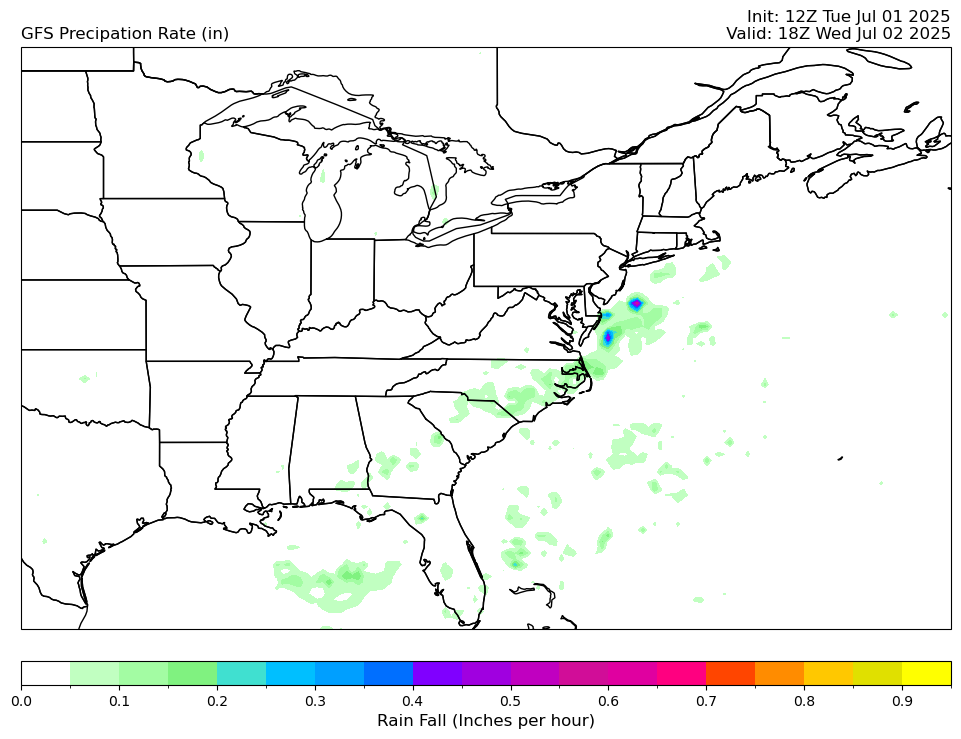

In [15]:
prate_mm = ds_time['prate']
prate_mm_hr = prate_mm*3600
prate_in_hr= prate_mm_hr*0.0393701
prate_colors = [
    "#ffffff",
    "#c1ffc1",
    "#a3fca3",
    "#80f280",
    "#40e0d0",
    "#00bfff",
    "#009fff",
    "#006fff",
    "#8000ff",
    "#a000e0",
    "#c000c0",
    "#d10d98",
    "#e000a0",
    "#ff0080",
    "#ff4500",
    "#ff8c00",
    "#ffc800",
    "#e0e000",
    "#ffff00",
]
prate_cmap = mcolors.ListedColormap(prate_colors)
prate_levels = np.arange(0, 1, 0.05)
prate_norm = mcolors.BoundaryNorm(prate_levels, len(prate_colors))     #Normalizes colors to levels
fig, ax = base_map()
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.03])     #Align colorbar with map
contour_prate = ax.contourf(ds_time['longitude'], ds_time['latitude'], prate_in_hr, levels=prate_levels, cmap=prate_cmap, norm=prate_norm, transform=ccrs.PlateCarree())
prate_color_bar = plt.colorbar(contour_prate, cax=cbar_ax, orientation='horizontal', pad=0.05)
prate_color_bar.set_label('Rain Fall (Inches per hour)', fontsize=12)
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('GFS Precipation Rate (in)', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)